# Branching Process: Referral Growth of a New App

## Real-life scenario

Suppose a startup launches a new app. In each week, an **active user** may invite some number of new users. We model the number of new users invited by one active user as a random variable $X$ with the following *observed* distribution:

$$
\mathbb{P}(X=0)=0.30,\quad
\mathbb{P}(X=1)=0.40,\quad
\mathbb{P}(X=2)=0.20,\quad
\mathbb{P}(X=3)=0.10.
$$

Let $Z_n$ denote the number of active users in week $n$, with initial condition

$$
Z_0 = 1.
$$

Then the process evolves as a **Galton–Watson branching process**:

$$
Z_{n+1} = \sum_{i=1}^{Z_n} X_{n,i},
$$

where the random variables $X_{n,i}$ are independent and identically distributed copies of $X$.

---

## Why this is a branching process

Each active user acts like an individual in a population. In the next generation (the next week), that individual produces a random number of “offspring,” namely the new users they invite. The total number of active users in the next generation is the sum of the offspring counts produced by all active users in the current generation.

---

## **Galton–Watson Branching Process**

A **Galton–Watson branching process** is a mathematical model for a population that evolves generation by generation, where each individual independently produces a random number of offspring.

### **Definition**

Let $Z_n$ denote the number of individuals in generation $n$. We start with

$$
Z_0 = 1
$$

or, more generally, with some fixed initial population size $Z_0 \geq 0$.

Suppose that each individual in generation $n$ produces a random number of children. If $X_{n,i}$ denotes the number of offspring produced by the $i$-th individual in generation $n$, then the next generation size is given by

$$
Z_{n+1} = \sum_{i=1}^{Z_n} X_{n,i}.
$$

Usually, we assume that all the random variables $X_{n,i}$ are independent and identically distributed.

### **Intuition**

This process can be viewed as a random family tree:

- generation $0$: one ancestor  
- generation $1$: children of that ancestor  
- generation $2$: grandchildren  
- and so on  

At each stage, the population may die out, remain small, or grow large depending on the offspring distribution.

### **Offspring Distribution**

Let $X$ denote the number of children produced by a typical individual. Then

$$
p_k = \mathbb{P}(X = k), \qquad k = 0,1,2,\dots
$$

is called the **offspring distribution**.

A key quantity is the mean number of offspring:

$$
m = \mathbb{E}[X].
$$

### **Main Behaviour**

The value of $m$ determines the broad behaviour of the process:

- If $m < 1$, the population tends to die out.  
- If $m = 1$, the process is called **critical**.  
- If $m > 1$, there is a positive chance that the population survives indefinitely.  

However, even when $m > 1$, extinction can still occur.

### **Example**

Suppose each individual has

$$
0 \text{ children with probability } \frac{1}{2},
\qquad
2 \text{ children with probability } \frac{1}{2}.
$$

Then

$$
m = 0 \cdot \frac{1}{2} + 2 \cdot \frac{1}{2} = 1.
$$

Hence, this is a critical branching process.

### **Generating Function**

A very useful tool is the probability generating function

$$
f(s) = \mathbb{E}[s^X] = \sum_{k=0}^{\infty} p_k s^k.
$$

If $q$ denotes the extinction probability, then $q$ is the smallest solution in $[0,1]$ of

$$
q = f(q).
$$

### **Summary**

A Galton–Watson branching process is a generation-by-generation random population model in which each individual independently produces a random number of offspring according to the same distribution.



---

## Key theoretical quantities

The **probability generating function** is

$$
f(s) = \mathbb{E}[s^X] = 0.3 + 0.4s + 0.2s^2 + 0.1s^3.
$$

The **mean number of offspring** is

$$
m = \mathbb{E}[X]
= 0\cdot 0.3 + 1\cdot 0.4 + 2\cdot 0.2 + 3\cdot 0.1
= 1.1.
$$

Hence the expected population size satisfies,

$$
\mathbb{E}[Z_n] = m^n = (1.1)^n.
$$

Since $m>1$, the process is **supercritical**, so there is a positive probability that the referral chain survives forever.

The **extinction probability** $q$ is the smallest solution in $[0,1]$ of

$$
q = f(q).
$$

We also simulate the process many times to compare theory with Monte Carlo behavior.

---



## Galton–Watson Branching Process

```text
                    A
                  /   \
                 B     C
                / \     \
               D   E     F
                    \
                     G

In [118]:
#Files provided

#This notebook works with the following CSV files:

#- `offspring_distribution.csv`
#- `analytical_expectation.csv`
#- `simulation_summary.csv`
#- `sample_paths.csv`
#- `key_results_summary.csv`

#The code below first loads the data, and then displays it in separate cells.

## 1. Import libraries

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

## 2. Load the CSV data

In [2]:

# Corrected folder path based on the search result
folder_path = "."

print(f"Loading data from: {folder_path}")

offspring_df = pd.read_csv(f"{folder_path}/offspring_distribution.csv")
analytical_df = pd.read_csv(f"{folder_path}/analytical_expectation.csv")
simulation_df = pd.read_csv(f"{folder_path}/simulation_summary.csv")
sample_paths_df = pd.read_csv(f"{folder_path}/sample_paths.csv")
summary_df = pd.read_csv(f"{folder_path}/key_results_summary.csv")

print("Data loaded successfully!")

Loading data from: .
Data loaded successfully!


In [121]:
import os

# Path to Google Drive root
drive_path = '/content/drive/MyDrive/'

print('Searching for "Branching_Process" folder in Google Drive...')
found_paths = []

for root, dirs, files in os.walk(drive_path):
    if 'Branching_Process' in dirs:
        full_path = os.path.join(root, 'Branching_Process')
        found_paths.append(full_path)

if found_paths:
    print('Found the following matching paths:')
    for p in found_paths:
        print(f'- {p}')
        print(f'  Contents: {os.listdir(p)}')
else:
    print('Could not find a folder named "Branching_Process".')
    print('\nTop-level folders in MyDrive are:')
    try:
        print(os.listdir(drive_path))
    except Exception as e:
        print(f'Error listing MyDrive: {e}')

Searching for "Branching_Process" folder in Google Drive...
Found the following matching paths:
- /content/drive/MyDrive/Colab Notebooks/ASP_2026/Branching_Process
  Contents: ['branching_process.ipynb', 'simulation_summary.csv', 'sample_paths.csv', 'key_results_summary.csv', 'offspring_distribution.csv', 'analytical_expectation.csv']


## 3. Display the loaded data

In [122]:
print("Offspring distribution:")
display(offspring_df)

print("\nAnalytical expectation:")
display(analytical_df)

print("\nSimulation summary:")
display(simulation_df)

print("\nKey results summary:")
display(summary_df)

print("\nFirst few sample paths:")
display(sample_paths_df.head())

Offspring distribution:


,new_users,probability
0,0,0.3
1,1,0.4
2,2,0.2
3,3,0.1



Analytical expectation:


,generation,expected_population
0,0,1.000000
1,1,1.100000
2,2,1.210000
3,3,1.331000
4,4,1.464100
5,5,1.610510
6,6,1.771561
7,7,1.948717
8,8,2.143589
9,9,2.357948



Simulation summary:


,generation,simulated_average_population,simulated_probability_extinct_by_generation
0,0,1.0000,0.0000
1,1,1.0893,0.3052
2,2,1.2065,0.4419
3,3,1.3300,0.5238
4,4,1.4456,0.5810
5,5,1.5848,0.6186
6,6,1.7330,0.6478
7,7,1.9059,0.6725
8,8,2.0887,0.6910
9,9,2.2989,0.7056



Key results summary:


,quantity,value
0,mean_offspring,1.100000
1,offspring_variance,0.890000
2,extinction_probability,0.791288
3,survival_probability,0.208712
4,expected_population_generation_5,1.610510
5,expected_population_generation_10,2.593742
6,simulated_average_population_generation_10,2.533000
7,simulated_probability_extinct_generation_10,0.716700
8,number_of_simulation_runs,10000.000000



First few sample paths:


,generation,path_1,path_2,path_3,path_4,path_5,path_6,path_7,path_8,path_9,...,path_11,path_12,path_13,path_14,path_15,path_16,path_17,path_18,path_19,path_20
0,0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
1,1,1,0,1,1,2,1,2,1,0,...,1,3,0,3,1,1,2,0,1,1
2,2,0,0,2,1,0,0,3,1,0,...,1,1,0,4,0,3,1,0,1,0
3,3,0,0,4,2,0,0,2,1,0,...,2,1,0,6,0,3,3,0,0,0
4,4,0,0,4,4,0,0,0,1,0,...,3,1,0,4,0,2,2,0,0,0


## 4. Define the branching-process functions

We now define the generating function, mean, variance, extinction probability, and simulation functions directly from the offspring distribution. This makes the notebook self-contained and shows how the theory connects to the data.


In [123]:
offspring_values = offspring_df["new_users"].to_numpy()
offspring_probs = offspring_df["probability"].to_numpy()

def generating_function(s):
    return float(np.sum(offspring_probs * (s ** offspring_values)))

def mean_offspring():
    return float(np.sum(offspring_values * offspring_probs))

def variance_offspring():
    m = mean_offspring()
    return float(np.sum(((offspring_values - m) ** 2) * offspring_probs))

def extinction_probability():
    # Solve q = f(q) numerically on [0,1]
    m = mean_offspring()
    if m <= 1:
        return 1.0

    def h(s):
        return generating_function(s) - s

    grid = np.linspace(0.0, 1.0, 10001)[:-1]
    vals = [h(x) for x in grid]

    idx = None
    for i in range(len(grid) - 1):
        if vals[i] == 0:
            return float(grid[i])
        if vals[i] * vals[i + 1] < 0:
            idx = i
            break

    if idx is None:
        return 1.0

    left = float(grid[idx])
    right = float(grid[idx + 1])

    for _ in range(100):
        mid = (left + right) / 2
        hm = h(mid)
        hl = h(left)
        if abs(hm) < 1e-14:
            return mid
        if hl * hm <= 0:
            right = mid
        else:
            left = mid

    return (left + right) / 2

def expected_population(n, z0=1):
    return z0 * (mean_offspring() ** n)

def sample_offspring(size):
    return np.random.choice(offspring_values, size=size, p=offspring_probs)

def simulate_branching_process(generations, z0=1, seed=None):
    if seed is not None:
        np.random.seed(seed)
    Z = [z0]
    for _ in range(generations):
        current = Z[-1]
        if current == 0:
            Z.append(0)
        else:
            Z.append(int(sample_offspring(current).sum()))
    return Z

def simulate_many(runs, generations, z0=1, seed=123):
    np.random.seed(seed)
    all_paths = np.zeros((runs, generations + 1), dtype=int)
    extinct_by_n = np.zeros(generations + 1, dtype=float)

    for r in range(runs):
        path = simulate_branching_process(generations, z0=z0)
        all_paths[r, :] = path
        extinct_by_n += (np.array(path) == 0).astype(float)

    extinct_by_n /= runs
    avg_pop = all_paths.mean(axis=0)
    return all_paths, avg_pop, extinct_by_n

## 5. Compute the main theoretical quantities

In [124]:
m = mean_offspring()
var = variance_offspring()
q = extinction_probability()

print(f"Mean offspring m = {m:.6f}")
print(f"Offspring variance = {var:.6f}")
print(f"Extinction probability q = {q:.6f}")
print(f"Survival probability 1 - q = {1-q:.6f}")

Mean offspring m = 1.100000
Offspring variance = 0.890000
Extinction probability q = 0.791288
Survival probability 1 - q = 0.208712


## 6. Compare the analytical expectation with the CSV data

The theory says

$$
\mathbb{E}[Z_n] = (1.1)^n.
$$

We compare the experimental CSV file against the values generated from the formula.


In [125]:
comparison_df = analytical_df.copy()
comparison_df["theoretical_formula_value"] = comparison_df["generation"].apply(expected_population)
comparison_df["difference"] = comparison_df["expected_population"] - comparison_df["theoretical_formula_value"]
display(comparison_df)

,generation,expected_population,theoretical_formula_value,difference
0,0,1.000000,1.000000,0.000000e+00
1,1,1.100000,1.100000,0.000000e+00
2,2,1.210000,1.210000,0.000000e+00
3,3,1.331000,1.331000,0.000000e+00
4,4,1.464100,1.464100,0.000000e+00
5,5,1.610510,1.610510,0.000000e+00
6,6,1.771561,1.771561,0.000000e+00
7,7,1.948717,1.948717,-4.440892e-16
8,8,2.143589,2.143589,0.000000e+00
9,9,2.357948,2.357948,0.000000e+00


## 7. Reproduce the simulation in code

In [126]:
runs = int(summary_df.loc[summary_df["quantity"] == "number_of_simulation_runs", "value"].iloc[0])
generations = int(analytical_df["generation"].max())

all_paths, avg_pop, extinct_by_n = simulate_many(runs=runs, generations=generations, seed=123)

recomputed_simulation_df = pd.DataFrame({
    "generation": np.arange(generations + 1),
    "simulated_average_population": avg_pop,
    "simulated_probability_extinct_by_generation": extinct_by_n
})

display(recomputed_simulation_df)

,generation,simulated_average_population,simulated_probability_extinct_by_generation
0,0,1.0000,0.0000
1,1,1.0893,0.3052
2,2,1.2065,0.4419
3,3,1.3300,0.5238
4,4,1.4456,0.5810
5,5,1.5848,0.6186
6,6,1.7330,0.6478
7,7,1.9059,0.6725
8,8,2.0887,0.6910
9,9,2.2989,0.7056


## 8. Plot theory versus simulation

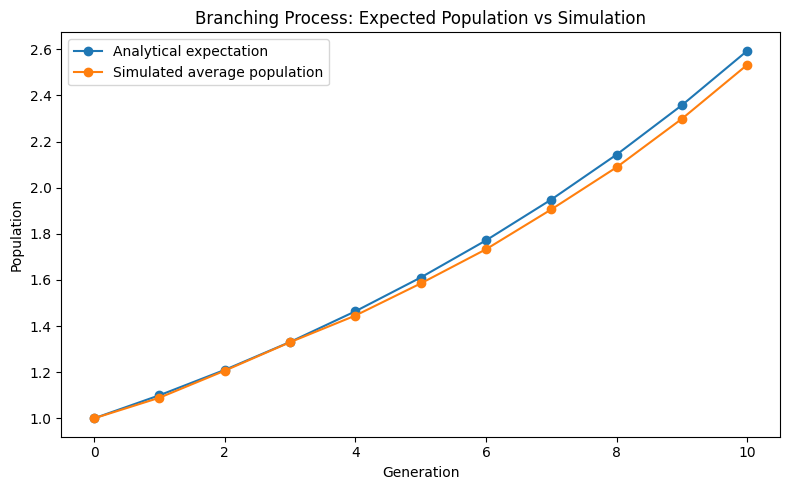

In [127]:
plt.figure(figsize=(8, 5))
plt.plot(
    analytical_df["generation"],
    analytical_df["expected_population"],
    marker="o",
    label="Analytical expectation"
)
plt.plot(
    simulation_df["generation"],
    simulation_df["simulated_average_population"],
    marker="o",
    label="Simulated average population"
)
plt.xlabel("Generation")
plt.ylabel("Population")
plt.title("Branching Process: Expected Population vs Simulation")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Display a few sample paths from the CSV file

In [128]:
display(sample_paths_df.iloc[:, :6])

,generation,path_1,path_2,path_3,path_4,path_5
0,0,1,1,1,1,1
1,1,1,0,1,1,2
2,2,0,0,2,1,0
3,3,0,0,4,2,0
4,4,0,0,4,4,0
5,5,0,0,4,3,0
6,6,0,0,3,3,0
7,7,0,0,4,5,0
8,8,0,0,6,5,0
9,9,0,0,3,6,0


## 10. Interpretation

1. The process is **supercritical** because \(m=1.1>1\).  
2. Even though the expected population grows like \((1.1)^n\), extinction is still quite likely.  
3. The numerical extinction probability is about \(0.7913\), so survival forever happens with probability about \(0.2087\).  
4. This is a common feature of branching processes: **average growth does not guarantee survival on every run**. Many sample paths die out early, while a smaller number grow and pull up the average.

---

## 11. Conclusion

This notebook shows how to:

- describe a real-life branching-process scenario,
- translate the theory into a mathematical model,
- load tabular data from CSV files,
- display the data in separate cells,
- compute theoretical quantities,
- simulate the process, and
- compare simulation with theory.
